# Imports

In [1]:
import numpy as np
import pandas as pd
from nsetools import Nse
from yahoofinancials import YahooFinancials
from sklearn.preprocessing import MinMaxScaler
import datetime
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
nse=Nse()

# Tickers Fetching from NSE

In [3]:
all_tickers=nse.get_stock_codes()

In [4]:
all_tickers

{'SYMBOL': 'NAME OF COMPANY',
 '20MICRONS': '20 Microns Limited',
 '21STCENMGM': '21st Century Management Services Limited',
 '3MINDIA': '3M India Limited',
 '3PLAND': '3P Land Holdings Limited',
 '5PAISA': '5Paisa Capital Limited',
 '63MOONS': '63 moons technologies limited',
 'A2ZINFRA': 'A2Z Infra Engineering Limited',
 'AAKASH': 'Aakash Exploration Services Limited',
 'AAREYDRUGS': 'Aarey Drugs & Pharmaceuticals Limited',
 'AARON': 'Aaron Industries Limited',
 'AARTIDRUGS': 'Aarti Drugs Limited',
 'AARTIIND': 'Aarti Industries Limited',
 'AARTISURF': 'Aarti Surfactants Limited',
 'AARVEEDEN': 'Aarvee Denims & Exports Limited',
 'AARVI': 'Aarvi Encon Limited',
 'AAVAS': 'Aavas Financiers Limited',
 'ABAN': 'Aban Offshore Limited',
 'ABB': 'ABB India Limited',
 'ABBOTINDIA': 'Abbott India Limited',
 'ABCAPITAL': 'Aditya Birla Capital Limited',
 'ABFRL': 'Aditya Birla Fashion and Retail Limited',
 'ABMINTLLTD': 'ABM International Limited',
 'ACC': 'ACC Limited',
 'ACCELYA': 'Accelya S

In [5]:
def ticker(s):
    l=[]
    for i in s:    
        l.append((list(all_tickers.keys())[list(all_tickers.values()).index(i)]))
    return l

In [6]:
tickers = ticker(["Sun Pharmaceutical Industries Limited",
"Divi's Laboratories Limited",
"Maruti Suzuki India Limited",
"Mahindra & Mahindra Limited",
"HDFC Bank Limited",
"ICICI Bank Limited",
"Infosys Limited",
"Tata Consultancy Services Limited",
"Tata Steel Limited",
"JSW Steel Limited"
])

In [7]:
tickers

['SUNPHARMA',
 'DIVISLAB',
 'MARUTI',
 'M&M',
 'HDFCBANK',
 'ICICIBANK',
 'INFY',
 'TCS',
 'TATASTEEL',
 'JSWSTEEL']

In [8]:
tickers = [s+'.NS' for s in tickers]
tickers

['SUNPHARMA.NS',
 'DIVISLAB.NS',
 'MARUTI.NS',
 'M&M.NS',
 'HDFCBANK.NS',
 'ICICIBANK.NS',
 'INFY.NS',
 'TCS.NS',
 'TATASTEEL.NS',
 'JSWSTEEL.NS']

# Fetching live stock data using Yahoo API

In [9]:
first_5=YahooFinancials(tickers[:10])

In [10]:
raw_data=first_5.get_historical_price_data("2016-01-01","2021-08-31","daily")

In [11]:
raw_data

{'SUNPHARMA.NS': {'eventsData': {'dividends': {'2020-08-19': {'amount': 1.0,
     'date': 1597808700,
     'formatted_date': '2020-08-19'},
    '2017-09-18': {'amount': 3.5,
     'date': 1505706300,
     'formatted_date': '2017-09-18'},
    '2018-09-17': {'amount': 2.0,
     'date': 1537155900,
     'formatted_date': '2018-09-17'},
    '2020-02-17': {'amount': 3.0,
     'date': 1581911100,
     'formatted_date': '2020-02-17'},
    '2019-08-20': {'amount': 2.75,
     'date': 1566272700,
     'formatted_date': '2019-08-20'},
    '2016-09-08': {'amount': 1.0,
     'date': 1473306300,
     'formatted_date': '2016-09-08'},
    '2021-02-09': {'amount': 5.5,
     'date': 1612842300,
     'formatted_date': '2021-02-09'},
    '2021-08-23': {'amount': 2.0,
     'date': 1629690300,
     'formatted_date': '2021-08-23'}}},
  'firstTradeDate': {'formatted_date': '1996-01-01', 'date': 820467900},
  'currency': 'INR',
  'instrumentType': 'EQUITY',
  'timeZone': {'gmtOffset': 19800},
  'prices': [{'dat

In [12]:
dfl = {}
for i in raw_data:
    dfl[i]=pd.DataFrame(raw_data[i]["prices"])

In [13]:
dflc=dfl.copy()

In [14]:
dflc

{'SUNPHARMA.NS':             date        high         low        open       close     volume  \
 0     1451619900  817.900024  806.200012  810.049988  815.549988   986728.0   
 1     1451879100  821.299988  795.099976  813.900024  799.099976  2388588.0   
 2     1451965500  807.000000  792.049988  807.000000  800.500000  1632394.0   
 3     1452051900  805.799988  790.750000  805.000000  791.950012  2168214.0   
 4     1452138300  799.000000  778.650024  788.000000  783.799988  2082334.0   
 ...          ...         ...         ...         ...         ...        ...   
 1392  1629776700  777.950012  754.250000  759.799988  771.349976  2732537.0   
 1393  1629863100  776.000000  759.599976  770.000000  769.049988  2254852.0   
 1394  1629949500  771.099976  759.250000  765.150024  760.549988  1735864.0   
 1395  1630035900  777.000000  758.099976  760.750000  771.799988  2432862.0   
 1396  1630295100  794.950012  768.150024  769.000000  787.200012  3617125.0   
 
         adjclose form

## NIFTY Scores from Yahoo API

In [15]:
nif = YahooFinancials('^NSEI')
nifty=pd.DataFrame(nif.get_historical_price_data("2016-01-01","2021-08-31","daily")['^NSEI']["prices"])["close"]

# Preprocessing

In [16]:
def pre_processing(df):
    df =  df.loc[:,["open","high","low","close","volume","formatted_date"]]
    df["formatted_date"] = pd.to_datetime(df["formatted_date"])
    df["Day of Week"]=df["formatted_date"].apply(lambda x : x.weekday())
    df["Day of Month"] = df["formatted_date"].apply(lambda x: int(x.strftime("%d")))
    df["Month"]=df["formatted_date"].apply(lambda x: int(x.strftime("%m")))
    df["Nifty"] = nifty
    df["close_pct"] = df["close"].pct_change()
    df["Range"] = df["high"] - df["low"]
    df = df.dropna()
    df.columns = ["Open","High","Low","Close","Volume","Date","Day of Week","Day of Month","Month","NIFTY50",'Range',"close_pct"]
    return df

In [17]:
for i in dflc:
    dflc[i] = pre_processing(dflc[i])

In [18]:
dflc.keys()

dict_keys(['SUNPHARMA.NS', 'DIVISLAB.NS', 'MARUTI.NS', 'M&M.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'TCS.NS', 'TATASTEEL.NS', 'JSWSTEEL.NS'])

# Splitting Train and Test data

In [19]:
split_date = datetime.datetime(2021,1,1)
df_train = {}
df_test = {}
df_train_Y = {}
df_test_Y = {}
for i in dflc:
    df_train[i] = dflc[i].loc[dflc[i]['Date'] < split_date].copy()
    df_test[i] = dflc[i].loc[dflc[i]['Date'] >= split_date].copy()
    df_train_Y[i] = dflc[i]['close_pct'].loc[dflc[i]['Date'] < split_date]
    df_test_Y[i] = dflc[i]['close_pct'].loc[dflc[i]['Date'] >= split_date]

In [20]:
df_train['ICICIBANK.NS']

,Open,High,Low,Close,Volume,Date,Day of Week,Day of Month,Month,NIFTY50,Range,close_pct
1,237.272720,237.590912,231.500000,232.318176,9435792.0,2016-01-04,0,4,1,7784.649902,-0.028327,6.090912
2,232.954544,234.090912,228.818176,233.363632,8966977.0,2016-01-05,1,5,1,7741.000000,0.004500,5.272736
3,232.181824,233.409088,226.545456,227.363632,17416181.0,2016-01-06,2,6,1,7568.299805,-0.025711,6.863632
4,224.000000,225.181824,221.000000,224.318176,18240712.0,2016-01-07,3,7,1,7601.350098,-0.013395,4.181824
5,222.272720,225.272720,221.318176,222.772720,14404391.0,2016-01-08,4,8,1,7563.850098,-0.006890,3.954544
...,...,...,...,...,...,...,...,...,...,...,...,...
1228,499.000000,505.500000,496.549988,503.600006,19205951.0,2020-12-23,2,23,12,13749.250000,0.006596,8.950012
1229,506.750000,515.950012,505.100006,513.549988,17576807.0,2020-12-24,3,24,12,13873.200195,0.019758,10.850006
1230,515.900024,521.200012,513.599976,520.099976,14470472.0,2020-12-28,0,28,12,13932.599609,0.012754,7.600037
1231,522.549988,530.799988,517.849976,528.799988,19092649.0,2020-12-29,1,29,12,13981.950195,0.016728,12.950012


In [21]:
df_train_Y['ICICIBANK.NS']

1        6.090912
2        5.272736
3        6.863632
4        4.181824
5        3.954544
          ...    
1228     8.950012
1229    10.850006
1230     7.600037
1231    12.950012
1232     8.450012
Name: close_pct, Length: 1225, dtype: float64

In [22]:
df_test['ICICIBANK.NS'].head()

,Open,High,Low,Close,Volume,Date,Day of Week,Day of Month,Month,NIFTY50,Range,close_pct
1234,535.549988,537.000000,526.099976,527.500000,13592625.0,2021-01-01,4,1,1,14132.900391,-0.014111,10.900024
1235,532.299988,535.000000,524.299988,531.700012,16549750.0,2021-01-04,0,4,1,14199.500000,0.007962,10.700012
1236,526.650024,539.950012,523.000000,537.250000,23311516.0,2021-01-05,1,5,1,14146.250000,0.010438,16.950012
1237,538.750000,550.599976,535.849976,546.700012,28178838.0,2021-01-06,2,6,1,14137.349609,0.017590,14.750000
1238,552.150024,554.400024,539.750000,541.099976,21138034.0,2021-01-07,3,7,1,14347.250000,-0.010243,14.650024


# Scaling Training and test data

In [23]:
scaler = MinMaxScaler()

In [24]:
#Normalize training data
df_train_X= {}

for i in df_train:  
     x = scaler.fit_transform(df_train[i][['Open', 'High','Low','Volume','NIFTY50','Range','Day of Week','Day of Month','Month']])
     df_train_X[i] = pd.DataFrame(data=x, columns = ['Open', 'High','Low','Volume','NIFTY50','Range','Day of Week','Day of Month','Month'])  

In [25]:
#Normalize test data
df_test_X = {}
for i in df_test:    
     x = scaler.transform(df_test[i][['Open', 'High','Low','Volume','NIFTY50','Range','Day of Week','Day of Month','Month']])
     df_test_X[i] = pd.DataFrame(data=x, columns = ['Open', 'High','Low','Volume','NIFTY50','Range','Day of Week','Day of Month','Month'])  

In [27]:
df_train_X['ICICIBANK.NS'].tail()

,Open,High,Low,Volume,NIFTY50,Range,Day of Week,Day of Month,Month
1220,0.867558,0.878117,0.878033,0.063312,0.966811,0.568838,0.50,0.733333,1.0
1221,0.887843,0.905391,0.900629,0.057611,0.984489,0.609291,0.75,0.766667,1.0
1222,0.911793,0.919093,0.923093,0.046740,0.992961,0.587766,0.00,0.900000,1.0
1223,0.929199,0.944148,0.934326,0.062916,1.000000,0.599978,0.25,0.933333,1.0
1224,0.953017,0.949890,0.952033,0.070869,0.999971,0.548274,0.50,0.966667,1.0


In [28]:
# df_train_X, df_test_X ---> Standardized features except 'close_pct'
# df_train_X, df_test_X ---> close_pct
# df_train, df_test  --> All features before standardization. Close price can be extracted from here for econometric test

#Pickling the data
output_resources= {'df_train_X':df_train_X, 'df_test_X':df_test_X,'df_train_Y':df_train_Y, 'df_test_Y':df_test_Y ,'df_train':df_train, 'df_test':df_test}
pickle.dump(output_resources,open( "resources_pickled.p", "wb" ))

# Training Data

In [29]:
stock_icici_forecast=df_train['ICICIBANK.NS'][['Date','Close']]

In [30]:
stock_icici_forecast.Date=stock_icici_forecast.Date.astype('datetime64[ns]')
#store1.Date=pd.DatetimeIndex(store1.Date)
stock_icici_forecast.set_index('Date',inplace=True)
stock_icici_forecast

,Close
Date,
2016-01-04,232.318176
2016-01-05,233.363632
2016-01-06,227.363632
2016-01-07,224.318176
2016-01-08,222.772720
...,...
2020-12-23,503.600006
2020-12-24,513.549988
2020-12-28,520.099976


In [31]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Close Price -ICICIBANK')

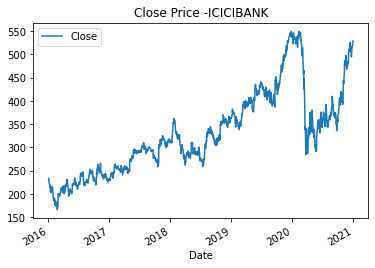

In [32]:
stock_icici_forecast.plot()
plt.title("Close Price -ICICIBANK")

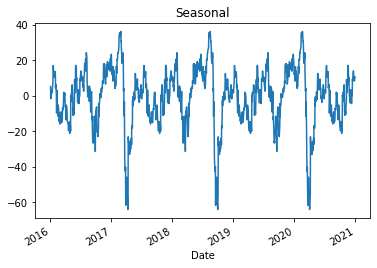

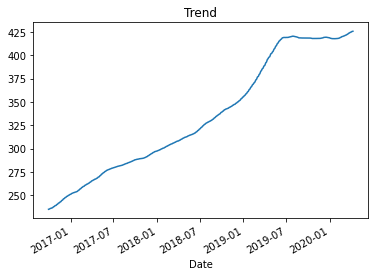

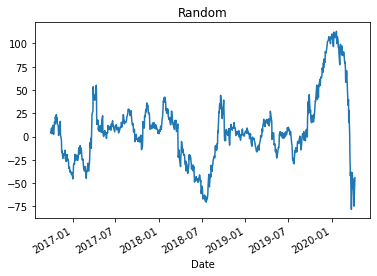

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(stock_icici_forecast,period=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

# Stationary Check

In [34]:
from statsmodels.tsa.stattools import adfuller
dftest = adfuller(stock_icici_forecast['Close'],autolag='AIC')
dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
print(dfoutput)

Test Statistic                   -1.325442
p-value                           0.617454
#lags used                       12.000000
number of observations used    1212.000000
critical value (1%)              -3.435757
critical value (5%)              -2.863928
critical value (10%)             -2.568041
dtype: float64


In [35]:
stock_icici_forecast['Close'] = stock_icici_forecast['Close'] - stock_icici_forecast['Close'].shift(1)
stock_icici_forecast['Close']

Date
2016-01-04         NaN
2016-01-05    1.045456
2016-01-06   -6.000000
2016-01-07   -3.045456
2016-01-08   -1.545456
                ...   
2020-12-23    3.300018
2020-12-24    9.949982
2020-12-28    6.549988
2020-12-29    8.700012
2020-12-30   -0.049988
Name: Close, Length: 1225, dtype: float64

In [36]:
from statsmodels.tsa.stattools import adfuller
dftest = adfuller(stock_icici_forecast['Close'].dropna(),autolag='AIC')
dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
print(dfoutput)

Test Statistic                -8.862775e+00
p-value                        1.467572e-14
#lags used                     1.100000e+01
number of observations used    1.212000e+03
critical value (1%)           -3.435757e+00
critical value (5%)           -2.863928e+00
critical value (10%)          -2.568041e+00
dtype: float64


In [37]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(stock_icici_forecast.dropna(),nlags=20)
print(ACFOutput)

[ 1.         -0.0451281  -0.0018216   0.0110665   0.01599533  0.0889742
 -0.07992536  0.00651892  0.0135667   0.03962855  0.04609847 -0.05209905
  0.08224794 -0.02672916 -0.0240651  -0.00206936 -0.05657596  0.07908473
 -0.01129018 -0.05870551  0.01838491]


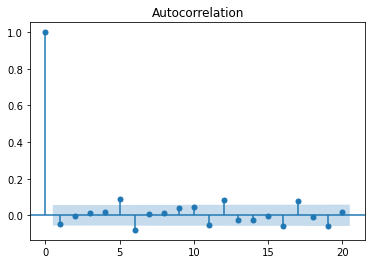

In [38]:
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
pltacf(stock_icici_forecast.dropna(),lags=20)
plt.show()

In [39]:
from  statsmodels.tsa.stattools import pacf as PACF
PACFOutput = PACF(stock_icici_forecast.dropna(),nlags=20)

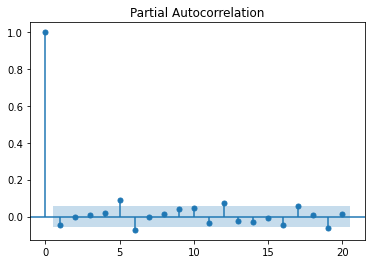

In [40]:
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
pltpacf(stock_icici_forecast.dropna(),lags=20).show()
plt.show()

In [41]:
from statsmodels.tsa.arima.model import ARIMA

In [43]:
stock_icici_forecast

,Close
Date,
2016-01-04,NaN
2016-01-05,1.045456
2016-01-06,-6.000000
2016-01-07,-3.045456
2016-01-08,-1.545456
...,...
2020-12-23,3.300018
2020-12-24,9.949982
2020-12-28,6.549988


In [44]:
icici_forecast=df_train['ICICIBANK.NS'][['Date','Close']]

In [45]:
icici_forecast.Date=icici_forecast.Date.astype('datetime64[ns]')
#store1.Date=pd.DatetimeIndex(store1.Date)
icici_forecast.set_index('Date',inplace=True)
icici_forecast

,Close
Date,
2016-01-04,232.318176
2016-01-05,233.363632
2016-01-06,227.363632
2016-01-07,224.318176
2016-01-08,222.772720
...,...
2020-12-23,503.600006
2020-12-24,513.549988
2020-12-28,520.099976


# Model Fitting

C:\Users\praveen\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\praveen\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\praveen\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'


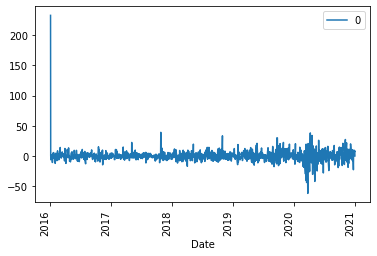

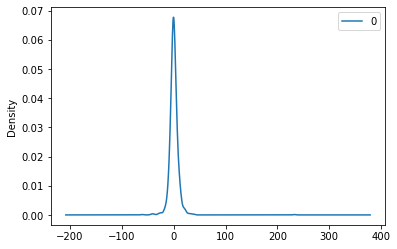

                 0
count  1225.000000
mean      0.442815
std      10.208094
min     -61.418476
25%      -3.480608
50%      -0.096339
75%       3.911912
max     232.318176


In [46]:
model = ARIMA(icici_forecast, order=(1,1,1))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

In [47]:
icici_forecast_test=df_test['ICICIBANK.NS'][['Date','Close']]
icici_forecast_test.Date=icici_forecast_test.Date.astype('datetime64[ns]')
#store1.Date=pd.DatetimeIndex(store1.Date)
icici_forecast_test.set_index('Date',inplace=True)
icici_forecast_test
icici_forecast_test_values=icici_forecast_test.values

In [48]:
icici_forecast.isnull().sum()

Close    0
dtype: int64

In [49]:
icici_forecast.values

array([[232.31817627],
       [233.3636322 ],
       [227.3636322 ],
       ...,
       [520.09997559],
       [528.79998779],
       [528.75      ]])

In [50]:
from sklearn.metrics import mean_squared_error

# Forecasting

In [52]:
history = [x for x in icici_forecast.values]
predictions = list()
for t in range(len(icici_forecast_test_values)):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = icici_forecast_test_values[t]
    history.append(obs)
    #print('predicted=%f, expected=%f' % (yhat, obs))
error = np.sqrt(mean_squared_error(icici_forecast_test_values, predictions))
print('Test Error Percentage',(error/np.mean(icici_forecast_test_values))*100)

Test Error Percentage 1.97476186412121
